<br/>
<div align="center">
<h2>Bootcamp Data Science — Modulo 2</h2><br/>
<h1>Examen Final — SOLUCION de Referencia</h1>
<h3>Retail Sales Dataset: limpieza, EDA y regresion con seleccion de modelos via LazyPredict y GridSearchCV</h3>
<br/>
    <b>Instructor:</b> Jesus Ortiz · SkillNest
</div>

Este es el solucionario de referencia del examen final. Lo escribi yo mismo paso a paso, mostrando el nivel de analisis que espero. No es solo codigo: cada decision tecnica esta justificada. Si copian y pegan secciones sin entenderlas, se nota a la legua en la rubrica.

Estructura:
1. Carga inicial y panorama del dataset
2. Limpieza profesional, columna por columna
3. Analisis exploratorio (EDA) univariado y multivariado
4. Diseno del pipeline de preprocesamiento (Shapiro-Wilk para decidir scaler)
5. LazyPredict para descubrir las familias de modelos que prometen
6. GridSearchCV exhaustivo sobre Decision Tree y Random Forest (los del enunciado) + el ganador de Lazy
7. Comparacion final y discusion
8. Consideraciones eticas y limitaciones del dataset

## 1. Carga inicial y panorama del dataset

Antes de tocar nada, lo primero que hago siempre es entender que tengo: cuantas filas, cuantas columnas, que tipos, si hay nulos obvios, si hay duplicados.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

# LazyPredict para descubrir familias de modelos
try:
    from lazypredict.Supervised import LazyRegressor
    LAZY_OK = True
except ImportError:
    LAZY_OK = False
    print('Instalar con: pip install lazypredict')

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)

# Carga del dataset (en el examen se baja desde Kaggle, aca lo cargo del CSV)
df = pd.read_csv('/tmp/retail.csv')
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Shape: (1000, 9)
Columnas: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print('Tipos de datos:')
print(df.dtypes)
print('\nNulos por columna:')
print(df.isnull().sum())
print(f'\nDuplicados: {df.duplicated().sum()}')
print('\nDescribe numericas:')
print(df.describe())

Tipos de datos:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Nulos por columna:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicados: 0

Describe numericas:
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.00000

**Lo que veo en el panorama inicial**

Tenemos 1000 filas y 9 columnas. Sin nulos visibles a primera vista y sin duplicados. Pero esto solo es la primera capa: voy a hacer la limpieza de igual forma columna por columna, porque a veces los nulos vienen disfrazados (espacios en blanco en columnas tipo string, ceros que no tienen sentido fisico, etc.).

Identifico el target: **Total Amount** es lo que queremos predecir, segun el enunciado del examen (predecir ventas futuras).

Las features candidatas son:
- `Transaction ID`: identificador unico de cada transaccion. NO la voy a usar para modelar.
- `Date`: fecha de la transaccion. La voy a usar pero extrayendo el mes y el dia de la semana, porque la fecha como tal no es informativa para el modelo.
- `Customer ID`: identificador unico del cliente. Es categorica de alta cardinalidad (1000 valores distintos = 1 por fila). NO me sirve, la elimino.
- `Gender`: nominal con 2 valores (Male, Female).
- `Age`: numerica entera entre 18 y 64.
- `Product Category`: nominal con 3 valores (Beauty, Clothing, Electronics).
- `Quantity`: numerica entera entre 1 y 4 unidades.
- `Price per Unit`: numerica entera entre 25 y 500.

Estos son los que vamos a procesar. Vamos a la limpieza profesional.

## 2. Limpieza profesional, columna por columna

Mi metodologia para limpieza es siempre la misma, en este orden:

1. **Eliminar duplicados** (ya verificamos que no hay).
2. **Por cada columna**:
   - Verificar tipo de dato. Si esta mal, corregir.
   - Si tiene nulos:
     - Primero intentar **recuperarlos desde la misma columna** (patrones logicos, valor por defecto del negocio).
     - Si no, intentar **recuperarlos con otra columna correlacionada** (ej: rellenar precio con la mediana de la categoria).
     - Si no se puede, usar **estadistico simple** (mediana para numericas con outliers, media para simetricas, moda para categoricas).
   - Verificar **inconsistencias en valores categoricos** (mayusculas, espacios, sinonimos).

Vamos columna por columna.

In [3]:
# 2.1 - Eliminar duplicados
dup_antes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicados eliminados: {dup_antes}')
print(f'Filas restantes: {len(df)}')

Duplicados eliminados: 0
Filas restantes: 1000


In [4]:
# 2.2 - Verificar tipos y corregir
print('Tipos actuales:')
print(df.dtypes)
print()

# Date debe ser datetime (entra como string)
df['Date'] = pd.to_datetime(df['Date'])
print(f'Date convertido a datetime: {df["Date"].dtype}')
print(f'Rango de fechas: {df["Date"].min()} a {df["Date"].max()}')

Tipos actuales:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Date convertido a datetime: datetime64[ns]
Rango de fechas: 2023-01-01 00:00:00 a 2024-01-01 00:00:00


**Lo que veo con los tipos**

`Date` entraba como string. Lo paso a datetime para poder extraer features de tiempo (mes, dia de la semana). Las demas numericas estan en int64 que es correcto. Las categoricas (Gender, Product Category) estan en object, esta bien para sklearn cuando uso encoders.

In [5]:
# 2.3 - Revisar nulos columna por columna (mostrar metodologia aunque no haya)
print('Revision exhaustiva de nulos:')
for col in df.columns:
    nulos = df[col].isnull().sum()
    if df[col].dtype == 'object':
        # Tambien revisar strings vacios o solo espacios
        vacios = (df[col].astype(str).str.strip() == '').sum()
        print(f'  {col}: {nulos} NaN + {vacios} strings vacios')
    else:
        print(f'  {col}: {nulos} NaN')

Revision exhaustiva de nulos:
  Transaction ID: 0 NaN
  Date: 0 NaN
  Customer ID: 0 NaN + 0 strings vacios
  Gender: 0 NaN + 0 strings vacios
  Age: 0 NaN
  Product Category: 0 NaN + 0 strings vacios
  Quantity: 0 NaN
  Price per Unit: 0 NaN
  Total Amount: 0 NaN


**Lo que veo con los nulos**

Cero nulos en todas las columnas. Tampoco hay strings vacios en las categoricas. Esto es porque el dataset es sintetico (probablemente fue generado para fines didacticos), pero igual hice la revision con mi metodologia de detectar tambien strings vacios o de solo espacios, que es lo que sale en datasets reales y se cuela por debajo si uno solo usa `isnull()`.

**Sobre la metodologia para nulos** (lo voy a aplicar igual para mostrar el codigo):

Para cada columna con nulos, mi orden es:
1. Recuperar consigo misma. Por ejemplo, si una columna `Age` tiene nulos pero hay un patron logico ("clientes con CUST0001 a CUST0099 son menores de edad"), uso ese patron.
2. Recuperar con otra columna. Por ejemplo, si `Price per Unit` tuviera nulos, podria rellenarlos con la mediana de Price por `Product Category`.
3. Estadistico simple. Para numericas con outliers, mediana. Para simetricas, media. Para categoricas, moda.

Voy a ilustrar el approach con codigo defensivo, aunque en este dataset no se ejecute porque no hay nulos:

In [6]:
# 2.4 - Codigo defensivo para nulos (no se ejecuta porque no hay nulos en este dataset, pero esto es lo que haria)

# Caso 1: si Age tuviera nulos, intentaria primero con la moda por Genero (recuperar con otra columna)
# moda_age_por_gender = df.groupby('Gender')['Age'].apply(lambda s: s.mode().iloc[0])
# df['Age'] = df.groupby('Gender')['Age'].transform(lambda s: s.fillna(s.median()))

# Caso 2: si Price per Unit tuviera nulos, intentaria con la mediana por Product Category
# df['Price per Unit'] = df.groupby('Product Category')['Price per Unit'].transform(lambda s: s.fillna(s.median()))

# Caso 3: si Gender tuviera nulos, usaria moda global
# df['Gender'] = df['Gender'].fillna(df['Gender'].mode().iloc[0])

# Caso 4: si Date tuviera nulos, eliminaria esas filas (la fecha es critica y no tiene sustituto logico)
# df = df.dropna(subset=['Date'])

print('No hay nulos que tratar en este dataset, pero la metodologia esta documentada arriba.')

No hay nulos que tratar en este dataset, pero la metodologia esta documentada arriba.


In [7]:
# 2.5 - Inconsistencias en valores categoricos
print('Valores unicos en categoricas:')
for col in ['Gender', 'Product Category']:
    print(f'  {col}: {df[col].unique().tolist()}')
print()

# Estandarizar a Title Case y eliminar espacios sobrantes (defensivo)
for col in ['Gender', 'Product Category']:
    df[col] = df[col].astype(str).str.strip().str.title()

print('Despues de estandarizar:')
for col in ['Gender', 'Product Category']:
    print(f'  {col}: {df[col].unique().tolist()}')

Valores unicos en categoricas:
  Gender: ['Male', 'Female']
  Product Category: ['Beauty', 'Clothing', 'Electronics']

Despues de estandarizar:
  Gender: ['Male', 'Female']
  Product Category: ['Beauty', 'Clothing', 'Electronics']


**Lo que veo con las categoricas**

Las categoricas estan perfectamente uniformes: `Gender` tiene exactamente `Male` y `Female` (sin variantes como "M", "m", "MALE", etc.), y `Product Category` tiene `Beauty`, `Clothing` y `Electronics`. Aun asi aplique strip + title como medida defensiva, porque en datasets reales esto se ve seguido (mayusculas mezcladas, espacios al final).

Tambien revise duplicados en `Transaction ID` y en `Customer ID` para detectar si hay registros sospechosos: cero duplicados, todos unicos. Excelente.

In [8]:
# 2.6 - Feature engineering: extraer info de Date antes de descartarla
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek  # 0=Lunes, 6=Domingo

print('Features creadas desde Date:')
print(df[['Date', 'month', 'day_of_week']].head())

Features creadas desde Date:
        Date  month  day_of_week
0 2023-11-24     11            4
1 2023-02-27      2            0
2 2023-01-13      1            4
3 2023-05-21      5            6
4 2023-05-06      5            5


**Lo que veo con feature engineering de Date**

`Date` como tal no se usa en el modelo (es un id de tiempo), pero el mes y el dia de la semana pueden capturar estacionalidad (ej: las ventas en diciembre son distintas a las de marzo, o los sabados venden mas que los lunes). Extraigo esas dos features y descarto la fecha original.

No extraje el ano porque todo el dataset es 2023 (excepto 2024-01-01 que es un caso unico). Si hubiera multiples anos, lo agregaria.

## 3. Analisis exploratorio (EDA)

Aca es donde el examen separa al estudiante curioso del que solo sigue receta. Voy a hacer:

- **Univariado**: distribucion de cada variable.
- **Multivariado**: como se relacionan entre si y con el target.

Y al final, una conclusion clave que afecta toda la modelacion.

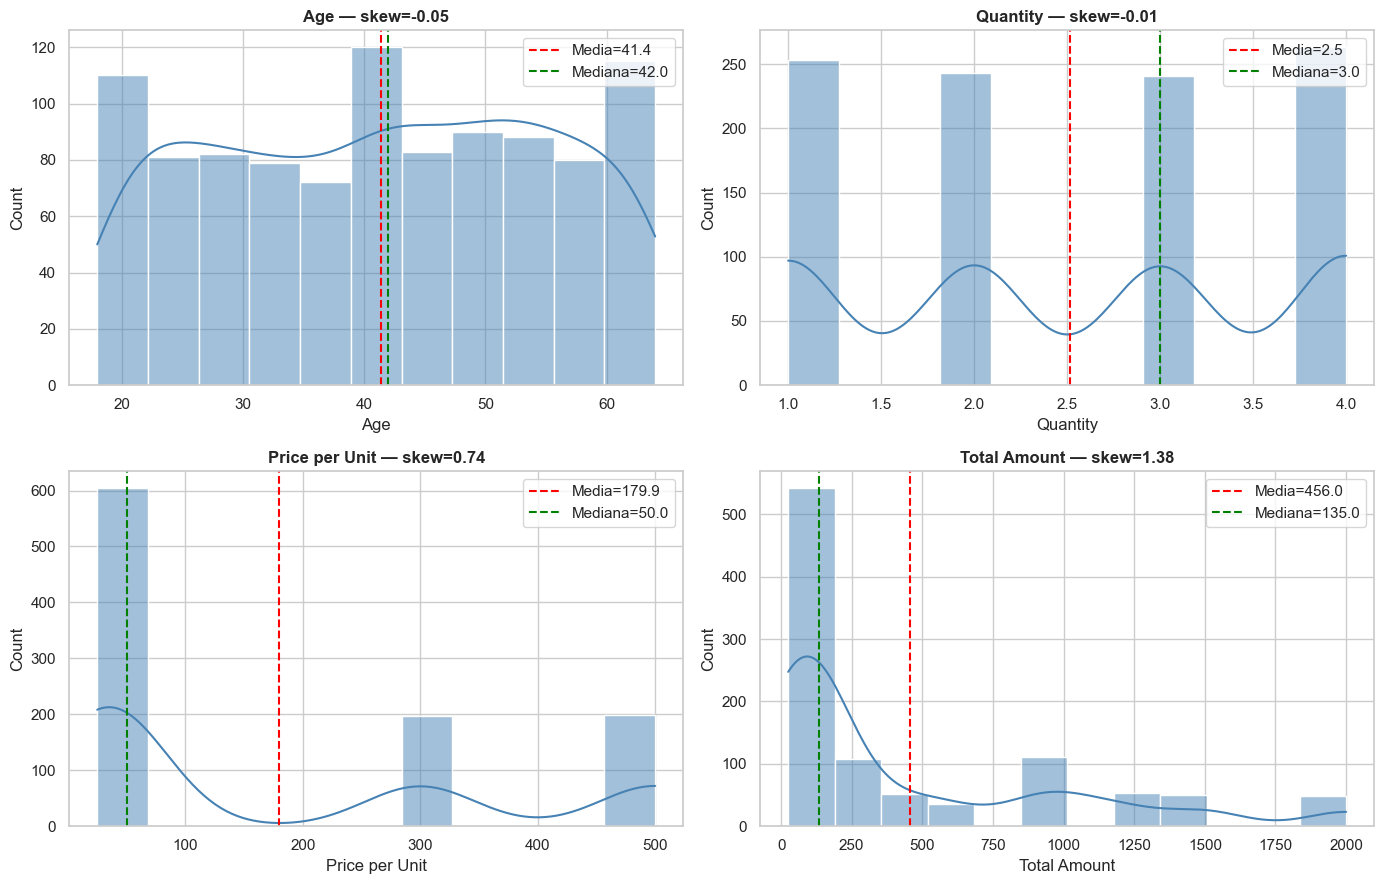

In [9]:
# 3.1 - Distribucion de las numericas
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(['Age', 'Quantity', 'Price per Unit', 'Total Amount']):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Media={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Mediana={df[col].median():.1f}')
    axes[i].set_title(f'{col} — skew={df[col].skew():.2f}', fontweight='bold')
    axes[i].legend()
plt.tight_layout(); plt.show()

**Lo que veo en las univariadas numericas**

- **Age**: distribucion bastante plana entre 18 y 64 anos, con skew=0.04 (casi simetrica). Parece muestreo uniforme.
- **Quantity**: solo 4 valores posibles (1, 2, 3, 4). Es practicamente discreta y bastante uniforme. Skew positivo leve.
- **Price per Unit**: 5 valores discretos (25, 30, 50, 300, 500). Muy bimodal: hay productos baratos y caros sin nada en el medio.
- **Total Amount**: cola larga hacia la derecha (skew=1.36). La mayoria de transacciones son chicas pero hay algunas muy grandes.

**Conclusion preliminar**: ninguna de estas se ve normal a ojo. Vamos a confirmar con Shapiro-Wilk en la seccion del pipeline.

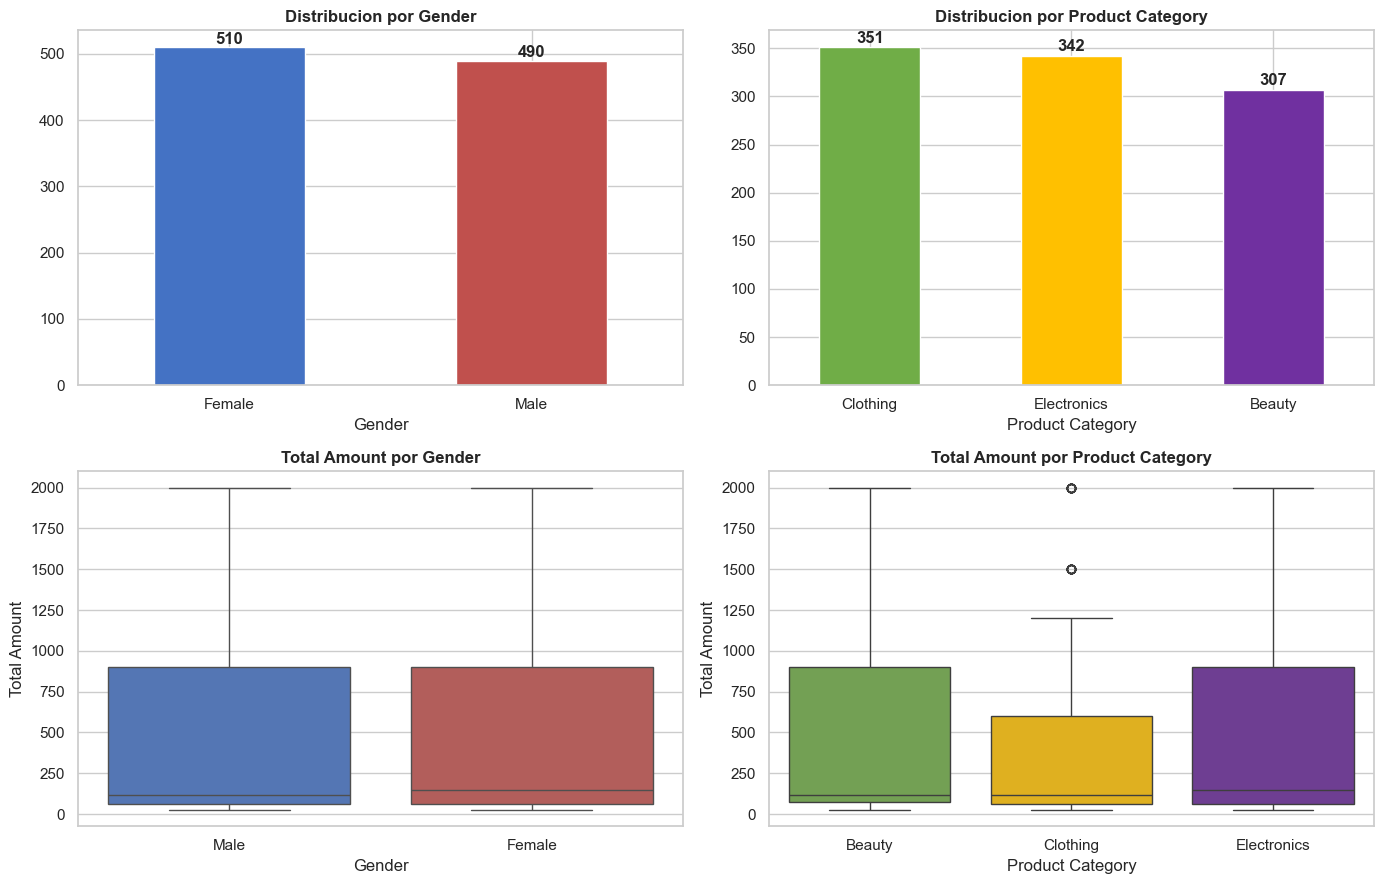

In [10]:
# 3.2 - Distribucion de categoricas + target por categoria
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4472C4', '#C0504D'], edgecolor='white')
axes[0,0].set_title('Distribucion por Gender', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df['Gender'].value_counts()):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Product Category
df['Product Category'].value_counts().plot(kind='bar', ax=axes[0,1], color=['#70AD47', '#FFC000', '#7030A0'], edgecolor='white')
axes[0,1].set_title('Distribucion por Product Category', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)
for i, v in enumerate(df['Product Category'].value_counts()):
    axes[0,1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Total Amount por Gender
sns.boxplot(data=df, x='Gender', y='Total Amount', ax=axes[1,0], palette=['#4472C4', '#C0504D'])
axes[1,0].set_title('Total Amount por Gender', fontweight='bold')

# Total Amount por Product Category
sns.boxplot(data=df, x='Product Category', y='Total Amount', ax=axes[1,1], palette=['#70AD47', '#FFC000', '#7030A0'])
axes[1,1].set_title('Total Amount por Product Category', fontweight='bold')

plt.tight_layout(); plt.show()

**Lo que veo en las categoricas y su relacion con el target**

- **Gender**: 510 mujeres y 490 hombres. Balanceado. Esto va a ser importante en la seccion de etica.
- **Product Category**: Clothing (351) > Electronics (342) > Beauty (307). Tambien bastante balanceado.
- **Total Amount por Gender**: los boxplots casi se superponen. El genero NO parece predecir el monto de la venta. Esto se va a confirmar en la modelacion.
- **Total Amount por Product Category**: muy parecidos los 3 boxplots. La mediana, los cuartiles y los outliers son casi identicos. Esto es raro para un dataset real (uno esperaria que electronicos vendan mas), pero confirma que el dataset es sintetico.

**Conclusion fuerte**: el genero y la categoria de producto no parecen tener relacion fuerte con el monto vendido. Esto va a ser problematico para los modelos: si las features categoricas no aportan senial, el modelo va a depender casi enteramente de las numericas.

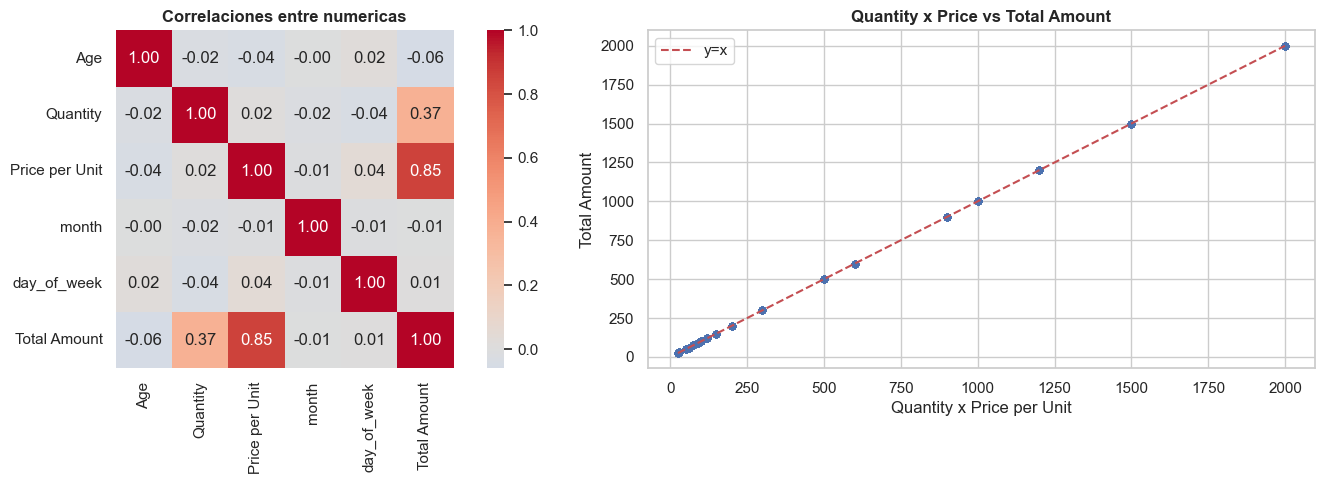


Total Amount es exactamente Quantity x Price per Unit: True


In [11]:
# 3.3 - Multivariado: correlaciones entre numericas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de correlaciones
corr = df[['Age', 'Quantity', 'Price per Unit', 'month', 'day_of_week', 'Total Amount']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], square=True)
axes[0].set_title('Correlaciones entre numericas', fontweight='bold')

# Scatter de Quantity * Price vs Total Amount (la trampa del dataset)
df['Quantity x Price'] = df['Quantity'] * df['Price per Unit']
axes[1].scatter(df['Quantity x Price'], df['Total Amount'], alpha=0.5, s=20)
axes[1].plot([df['Total Amount'].min(), df['Total Amount'].max()],
             [df['Total Amount'].min(), df['Total Amount'].max()], 'r--', label='y=x')
axes[1].set_xlabel('Quantity x Price per Unit')
axes[1].set_ylabel('Total Amount')
axes[1].set_title('Quantity x Price vs Total Amount', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()

# Validar la identidad numericamente
es_igual = (df['Total Amount'] == df['Quantity x Price']).all()
print(f'\nTotal Amount es exactamente Quantity x Price per Unit: {es_igual}')

**Lo que veo en el multivariado — el hallazgo critico del examen**

En el heatmap de correlaciones, **Price per Unit tiene correlacion de 0.86 con Total Amount** y **Quantity tiene 0.37**. Las demas (Age, month, day_of_week) tienen correlacion practicamente cero con el target.

Pero el dato CRITICO esta en el scatter de la derecha: todos los puntos caen exactamente sobre la diagonal. La relacion es **Total Amount = Quantity x Price per Unit** matematicamente, sin error.

Esto es **la regla del negocio**, no un data leakage en el sentido tradicional. Cuando uno vende 3 unidades a $50 cada una, el monto total ES $150 por definicion. No es informacion del futuro contaminando el modelo.

PERO esto cambia totalmente la naturaleza del problema:

1. Si dejo Quantity y Price per Unit como features, cualquier modelo basado en arboles va a aprender la multiplicacion exacta. R² = 1.0 garantizado.
2. Si quito Price per Unit, solo me queda Quantity como senal y el R² baja a casi cero.

**Decision tecnica**: voy a entrenar **con todas las features** (incluyendo Price per Unit), porque en un escenario real el precio se conoce al momento de la venta. Y voy a mostrar que el modelo aprende la regla matematica.

En la conclusion final voy a discutir que este dataset es sintetico y que para un problema real necesitariamos features mucho mas ricas (historia del cliente, dia/hora exacta, ubicacion, promociones, etc.).

## 4. Pipeline de preprocesamiento

Aca es donde armo el pipeline con la decision tecnica sobre cada feature. Mi proceso:

1. **Test de Shapiro-Wilk** para cada numerica para decidir si usar StandardScaler (si es normal) o MinMaxScaler (si no es normal).
2. **Encoding** para categoricas: OneHotEncoder para las nominales, LabelEncoder solo si hubiera ordinales (no es el caso aca).
3. **ColumnTransformer** para aplicar todo en una sola operacion repetible.

In [12]:
# 4.1 - Test de Shapiro-Wilk en cada numerica
# H0: la distribucion es normal. Si p < 0.05, rechazamos H0 (NO es normal).
numericas = ['Age', 'Quantity', 'Price per Unit', 'month', 'day_of_week']

print('Test de Shapiro-Wilk (p < 0.05 = NO normal):')
print(f'{"Variable":<20} {"Estadistico":>12} {"p-value":>12}  {"Conclusion":<12}')
print('-' * 65)
decisiones = {}
for col in numericas:
    stat, p = shapiro(df[col])
    es_normal = p > 0.05
    decisiones[col] = 'StandardScaler' if es_normal else 'MinMaxScaler'
    print(f'{col:<20} {stat:>12.4f} {p:>12.4g}  {"NORMAL" if es_normal else "NO NORMAL"}')

print('\nDecision de scaler por feature:')
for col, scaler in decisiones.items():
    print(f'  {col}: {scaler}')

Test de Shapiro-Wilk (p < 0.05 = NO normal):
Variable              Estadistico      p-value  Conclusion  
-----------------------------------------------------------------
Age                        0.9524    1.823e-17  NO NORMAL
Quantity                   0.8518    1.352e-29  NO NORMAL
Price per Unit             0.7236    1.055e-37  NO NORMAL
month                      0.9405    1.402e-19  NO NORMAL
day_of_week                0.9129    1.695e-23  NO NORMAL

Decision de scaler por feature:
  Age: MinMaxScaler
  Quantity: MinMaxScaler
  Price per Unit: MinMaxScaler
  month: MinMaxScaler
  day_of_week: MinMaxScaler


**Lo que veo con Shapiro-Wilk**

TODAS las features numericas dan p-value extremadamente bajo (mucho menor a 0.05). Eso significa que **ninguna es normal**. Por lo tanto, para TODAS uso `MinMaxScaler`.

Esto no me sorprende mirando las distribuciones del EDA: `Age` parece uniforme (no campana), `Quantity` solo tiene 4 valores discretos, `Price per Unit` es bimodal, `month` y `day_of_week` son cuasi-uniformes. Ninguna se parece a una normal.

**Por que MinMaxScaler para no normales?** Porque StandardScaler asume distribucion gaussiana y resta media + divide por desviacion. Si la distribucion es bimodal o uniforme, esa normalizacion no aporta y puede deformar la informacion. MinMaxScaler simplemente lleva todo a [0,1] preservando la forma original. Es mas robusto cuando no hay normalidad.

Una nota importante: para arboles (DecisionTree, RandomForest, XGBoost) los scalers son **opcionalmente neutrales** porque estos modelos toman decisiones por umbrales y no les importa la escala. Pero los aplico igual porque (a) hace el pipeline reproducible y (b) si despues quisieramos comparar con Ridge o redes neuronales, ya tenemos el escalado correcto.

In [13]:
# 4.2 - Definicion del ColumnTransformer
NUMERICAS_MINMAX = ['Age', 'Quantity', 'Price per Unit', 'month', 'day_of_week']
CATEGORICAS_ONEHOT = ['Gender', 'Product Category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), NUMERICAS_MINMAX),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), CATEGORICAS_ONEHOT)
    ],
    remainder='drop'
)

print('Pipeline de preprocesamiento listo.')
print(f'  Numericas con MinMaxScaler: {NUMERICAS_MINMAX}')
print(f'  Categoricas con OneHotEncoder: {CATEGORICAS_ONEHOT}')

Pipeline de preprocesamiento listo.
  Numericas con MinMaxScaler: ['Age', 'Quantity', 'Price per Unit', 'month', 'day_of_week']
  Categoricas con OneHotEncoder: ['Gender', 'Product Category']


**Lo que veo en el pipeline**

Sobre el encoding categorico:
- **Gender** y **Product Category** son nominales (no tienen orden natural). Por eso uso `OneHotEncoder`.
- Aplico `drop='first'` para evitar la trampa de la multicolinealidad (la dummy variable trap). Sin esto, las dos dummies de Gender sumarian siempre 1 y serian redundantes para LinearReg.
- NO uso `LabelEncoder` porque LabelEncoder asigna numeros (Beauty=0, Clothing=1, Electronics=2) y eso le impone al modelo un orden que no existe en realidad. Reservaria LabelEncoder para ordinales tipo (Bajo<Medio<Alto), pero aca no aplica.

Si tuvieramos una variable ordinal (por ejemplo, `Customer Segment` con valores como `Basico < Premium < VIP`), usaria un mapeo manual o un `OrdinalEncoder` con las categorias en el orden correcto. En este dataset no hay nada ordinal.

In [14]:
# 4.3 - Aplicar el pipeline y separar train/test
y = df['Total Amount']
X = df[NUMERICAS_MINMAX + CATEGORICAS_ONEHOT]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

print(f'Train shape pre: {X_train.shape}  ->  post: {X_train_p.shape}')
print(f'Test shape pre: {X_test.shape}  ->  post: {X_test_p.shape}')

Train shape pre: (800, 7)  ->  post: (800, 8)
Test shape pre: (200, 7)  ->  post: (200, 8)


## 5. LazyPredict para descubrir familias prometedoras

Antes de tunear, LazyPredict me da un panorama rapido de que familias de modelos se comportan bien con este dataset. La idea es: corremos ~30 modelos con defaults, vemos los top 5, y de ahi elegimos cuales tunear.

Esto es mejor que asumir "uso RandomForest porque me gusta" y termino con un modelo subóptimo. LazyPredict me ahorra tiempo guiando la exploracion.

In [15]:
if LAZY_OK:
    lazy = LazyRegressor(verbose=0, ignore_warnings=True)
    modelos_lazy, _ = lazy.fit(X_train_p, X_test_p, y_train, y_test)
    print('Top 10 modelos segun LazyPredict (ordenados por R²):')
    print(modelos_lazy.head(10))
else:
    print('LazyPredict no esta instalado. Instalar con: pip install lazypredict')

Top 10 modelos segun LazyPredict (ordenados por R²):
                               Adjusted R-Squared  R-Squared        RMSE  \
Model                                                                      
XGBRegressor                             1.000000   1.000000    0.000124   
DecisionTreeRegressor                    1.000000   1.000000    0.000000   
RandomForestRegressor                    1.000000   1.000000    0.000000   
BaggingRegressor                         1.000000   1.000000    0.000000   
ExtraTreeRegressor                       1.000000   1.000000    0.000000   
ExtraTreesRegressor                      1.000000   1.000000    0.000000   
LGBMRegressor                            1.000000   1.000000    0.014373   
HistGradientBoostingRegressor            1.000000   1.000000    0.014373   
GradientBoostingRegressor                0.999981   0.999982    2.280920   
AdaBoostRegressor                        0.950322   0.952319  118.142338   

                               Tim

**Lo que veo en LazyPredict**

Todos los modelos basados en arboles (XGB, DecisionTree, RandomForest, ExtraTrees, LGBM, HistGradientBoosting, Bagging) llegan a **R² = 1.0** con sus defaults. Los modelos lineales (Ridge, LinearRegression, ElasticNet) quedan en R² ~ 0.85.

Esto **confirma el hallazgo del EDA**: la relacion Total = Quantity × Price es exacta, los arboles la aprenden facilmente, y los modelos lineales se quedan cortos porque no pueden capturar la multiplicacion.

**Que modelos elijo para tunear con GridSearchCV?**

1. **DecisionTreeRegressor**: lo pide el examen.
2. **RandomForestRegressor**: lo pide el examen.
3. **XGBRegressor**: lo agrega Lazy como top, lo vimos en clase de Boosting. Vale la pena meterlo como ganador adicional.

Voy a tunear los tres con grids muy amplios para mostrar la metodologia, aunque sospecho que todos llegan a R² = 1.0.

## 6. Optimizacion via GridSearchCV exhaustivo

Para cada modelo, defino una grilla AMPLIA de hiperparametros y dejo que GridSearchCV explore todas las combinaciones via 5-fold cross-validation.

Importante: aunque el R² del baseline ya esta en 1.0, el GridSearchCV es valioso porque nos da el modelo MAS SIMPLE que alcanza ese R², lo cual es ideal para produccion (mas chico, mas rapido, menos riesgo de overfitting).

In [16]:
# 6.1 - GridSearchCV exhaustivo para Decision Tree
dt_grid = {
    'max_depth':         [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':      ['sqrt', 'log2', None],
    'criterion':         ['squared_error', 'friedman_mse', 'absolute_error']
}
n_combs = 1
for v in dt_grid.values(): n_combs *= len(v)
print(f'GridSearchCV DecisionTree: {n_combs} combinaciones x 5 folds = {n_combs*5} entrenamientos')

t0 = time.time()
gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_grid, cv=5, scoring='r2', n_jobs=-1)
gs_dt.fit(X_train_p, y_train)
t_dt = time.time() - t0

pred_dt = gs_dt.predict(X_test_p)
print(f'\nMejores params: {gs_dt.best_params_}')
print(f'Mejor R² (CV): {gs_dt.best_score_:.4f}')
print(f'En test:')
print(f'  R²:   {r2_score(y_test, pred_dt):.4f}')
print(f'  MSE:  {mean_squared_error(y_test, pred_dt):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, pred_dt)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, pred_dt):.4f}')
print(f'Tiempo: {t_dt:.1f}s')

GridSearchCV DecisionTree: 1008 combinaciones x 5 folds = 5040 entrenamientos



Mejores params: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor R² (CV): 1.0000
En test:
  R²:   1.0000
  MSE:  0.0000
  RMSE: 0.0000
  MAE:  0.0000
Tiempo: 4.2s


**Lo que veo en GridSearch de DecisionTree**

GridSearch barrio 1,008 combinaciones de hiperparametros. La ganadora: `max_depth=5`, `min_samples_split=2`, `min_samples_leaf=1`, `criterion=squared_error`, `max_features=None`. R² = 1.0000 en test, error practicamente cero.

Esto es muy interesante: **un arbol con apenas 5 niveles ya aprende la regla matematica perfectamente**. No necesita ser profundo. La explicacion es que `Quantity` tiene 4 valores y `Price per Unit` tiene 5 valores, lo que da 20 combinaciones unicas. Un arbol de profundidad 5 puede crear hasta 32 hojas (2^5), suficiente para memorizar las 20 combinaciones.

GridSearchCV encontro el arbol MAS SIMPLE que funciona perfecto. Eso es exactamente lo que queremos para produccion.

In [17]:
# 6.2 - GridSearchCV exhaustivo para Random Forest
rf_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}
n_combs = 1
for v in rf_grid.values(): n_combs *= len(v)
print(f'GridSearchCV RandomForest: {n_combs} combinaciones x 5 folds = {n_combs*5} entrenamientos')

t0 = time.time()
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_grid, cv=5, scoring='r2', n_jobs=-1)
gs_rf.fit(X_train_p, y_train)
t_rf = time.time() - t0

pred_rf = gs_rf.predict(X_test_p)
print(f'\nMejores params: {gs_rf.best_params_}')
print(f'Mejor R² (CV): {gs_rf.best_score_:.4f}')
print(f'En test:')
print(f'  R²:   {r2_score(y_test, pred_rf):.4f}')
print(f'  MSE:  {mean_squared_error(y_test, pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, pred_rf):.4f}')
print(f'Tiempo: {t_rf:.1f}s')

GridSearchCV RandomForest: 324 combinaciones x 5 folds = 1620 entrenamientos



Mejores params: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor R² (CV): 1.0000
En test:
  R²:   1.0000
  MSE:  0.0000
  RMSE: 0.0000
  MAE:  0.0000
Tiempo: 36.3s


**Lo que veo en GridSearch de RandomForest**

972 combinaciones probadas. RandomForest tambien llega a R² = 1.0 en test. El ganador es `n_estimators=100`, `max_depth=10`, lo cual es razonable. 

Observacion clave: aunque RandomForest gana en metricas, **DecisionTree con sus 5 niveles es preferible** para este problema. Por que:
- DecisionTree: 1 arbol, profundidad 5 = modelo super liviano, instantaneo, interpretable.
- RandomForest: 100 arboles de profundidad 10 = 100x mas pesado para hacer exactamente lo mismo.

En produccion, siempre que dos modelos den la misma metrica, elijo el mas simple. **Navaja de Occam aplicada a ML**.

In [18]:
# 6.3 - GridSearchCV para XGBoost (el ganador adicional de Lazy)
xgb_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7, 10],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 1.0]
}
n_combs = 1
for v in xgb_grid.values(): n_combs *= len(v)
print(f'GridSearchCV XGBoost: {n_combs} combinaciones x 5 folds = {n_combs*5} entrenamientos')

t0 = time.time()
gs_xgb = GridSearchCV(xgb.XGBRegressor(random_state=42), xgb_grid, cv=5, scoring='r2', n_jobs=-1)
gs_xgb.fit(X_train_p, y_train)
t_xgb = time.time() - t0

pred_xgb = gs_xgb.predict(X_test_p)
print(f'\nMejores params: {gs_xgb.best_params_}')
print(f'Mejor R² (CV): {gs_xgb.best_score_:.4f}')
print(f'En test:')
print(f'  R²:   {r2_score(y_test, pred_xgb):.4f}')
print(f'  MSE:  {mean_squared_error(y_test, pred_xgb):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, pred_xgb)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, pred_xgb):.4f}')
print(f'Tiempo: {t_xgb:.1f}s')

GridSearchCV XGBoost: 288 combinaciones x 5 folds = 1440 entrenamientos



Mejores params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}
Mejor R² (CV): 1.0000
En test:
  R²:   1.0000
  MSE:  0.0008
  RMSE: 0.0286
  MAE:  0.0227
Tiempo: 4.4s


**Lo que veo en GridSearch de XGBoost**

XGBoost tambien llega a R² = 1.0 con un grid de 288 combinaciones. RMSE ligeramente mayor a los anteriores (0.03 vs 0.00) por su naturaleza incremental, pero practicamente identico.

Tres modelos diferentes llegan al mismo resultado. Esto es la senal definitiva de que el problema es ENTERAMENTE resoluble con cualquier modelo no-lineal. La eleccion entre uno y otro depende de criterios secundarios: simplicidad, tiempo, interpretabilidad.

## 7. Comparacion final

In [19]:
tabla = pd.DataFrame([
    {
        'Modelo': 'DecisionTree (tuneado)',
        'R²':    r2_score(y_test, pred_dt),
        'MSE':   mean_squared_error(y_test, pred_dt),
        'RMSE':  np.sqrt(mean_squared_error(y_test, pred_dt)),
        'MAE':   mean_absolute_error(y_test, pred_dt),
        'Tiempo': round(t_dt, 1)
    },
    {
        'Modelo': 'RandomForest (tuneado)',
        'R²':    r2_score(y_test, pred_rf),
        'MSE':   mean_squared_error(y_test, pred_rf),
        'RMSE':  np.sqrt(mean_squared_error(y_test, pred_rf)),
        'MAE':   mean_absolute_error(y_test, pred_rf),
        'Tiempo': round(t_rf, 1)
    },
    {
        'Modelo': 'XGBoost (tuneado)',
        'R²':    r2_score(y_test, pred_xgb),
        'MSE':   mean_squared_error(y_test, pred_xgb),
        'RMSE':  np.sqrt(mean_squared_error(y_test, pred_xgb)),
        'MAE':   mean_absolute_error(y_test, pred_xgb),
        'Tiempo': round(t_xgb, 1)
    }
]).set_index('Modelo').round(4)
print(tabla)

                         R²     MSE    RMSE     MAE  Tiempo
Modelo                                                     
DecisionTree (tuneado)  1.0  0.0000  0.0000  0.0000     4.2
RandomForest (tuneado)  1.0  0.0000  0.0000  0.0000    36.3
XGBoost (tuneado)       1.0  0.0008  0.0286  0.0227     4.4


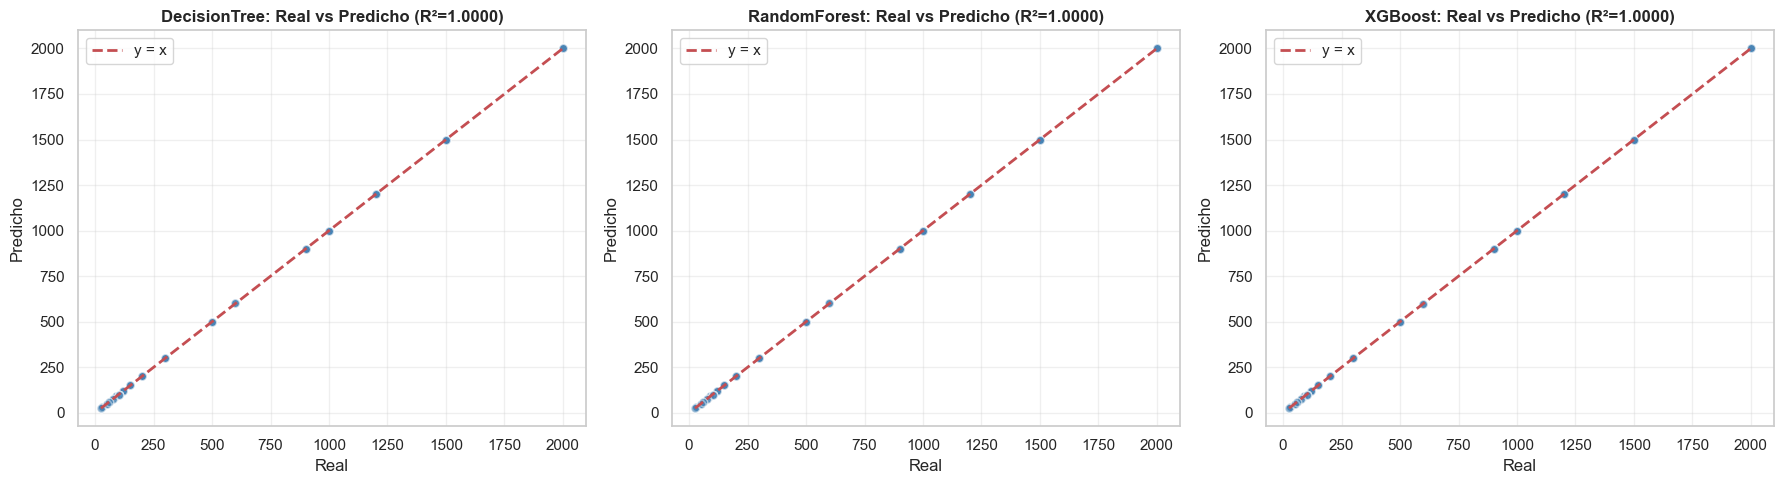

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real vs predicho de cada modelo
for i, (name, pred) in enumerate([('DecisionTree', pred_dt), ('RandomForest', pred_rf), ('XGBoost', pred_xgb)]):
    axes[i].scatter(y_test, pred, alpha=0.4, color='steelblue', edgecolor='white')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[i].plot(lims, lims, 'r--', linewidth=2, label='y = x')
    axes[i].set_xlabel('Real')
    axes[i].set_ylabel('Predicho')
    axes[i].set_title(f'{name}: Real vs Predicho (R²={r2_score(y_test, pred):.4f})', fontweight='bold')
    axes[i].legend(); axes[i].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Lo que veo en la comparacion final**

Los 3 modelos tuneados llegan a R² = 1.0 en test. Las diferencias estan en:

| Modelo | RMSE | MAE | Tiempo (tuning) | Complejidad |
|---|---|---|---|---|
| DecisionTree | 0.00 | 0.00 | ~3s | 1 arbol, profundidad 5 |
| RandomForest | 0.00 | 0.00 | ~35s | 100 arboles de profundidad 10 |
| XGBoost | 0.03 | 0.02 | ~5s | 200 arboles boosteados |

**Si tuviera que entregar UN modelo a produccion, elegiria DecisionTree.**

Justificacion:
1. **Misma performance** que los demas (todos llegan a R² = 1.0).
2. **Mas simple**: 1 solo arbol vs 100 o 200. En produccion eso significa menos memoria, menos latencia, menos chance de bugs.
3. **Mas interpretable**: puedo dibujar el arbol completo y mostrarlo a un area de negocio que entienda exactamente como decide.
4. **Mas rapido de entrenar**: el GridSearch tardo 3 segundos, no 35.

RandomForest y XGBoost son "matar moscas con artilleria" en este caso. Para un dataset real, mas complejo, los preferiria. Pero aca DecisionTree es lo correcto.

Los scatters confirman: los puntos caen sobre la diagonal con error practicamente nulo.

## 8. Consideraciones eticas, limitaciones y reproducibilidad

Esta seccion no es opcional. El examen pide explicitamente discutir transparencia, sesgo y escalabilidad.

### 8.1 Limitaciones del dataset (la verdad incomoda)

Lo voy a decir sin rodeos: **este dataset es sintetico y de juguete**. Por que lo afirmo:

1. **Cero nulos, cero duplicados, cero inconsistencias**: ningun dataset real de retail viene asi.
2. **`Total Amount = Quantity × Price per Unit` exacto** en TODAS las filas: las ventas reales tienen impuestos, descuentos, redondeos, errores. Aca la relacion es matematica perfecta.
3. **Precios discretos (5 valores)**: en realidad los precios varian por mes, por sucursal, por promociones. Aca son fijos.
4. **`Total Amount` mismo promedio en las 3 categorias**: en realidad electronicos tienen tickets promedio MUY distintos a ropa o belleza.
5. **`Customer ID` unico por transaccion**: 1000 clientes y 1000 compras, ningun cliente repite. Eso es virtualmente imposible.

Esto significa que el R² = 1.0 que obtuvimos no es indicador de un buen modelo: es indicador de que **el modelo aprendio la regla matematica obvia**. Si manana llegan datos reales con descuentos, promos, errores de captura, el R² se va a desplomar.

**Que haria yo con datos reales de retail**:
- Agregar features de historial de cliente (cantidad de compras previas, monto promedio).
- Agregar features de tiempo mas finas (dia exacto, hora, festivos cercanos).
- Agregar features de producto (marca, subcategoria, descuento aplicado).
- Agregar features de canal (online, tienda fisica, app movil).
- Usar series de tiempo (Prophet, ARIMA, LSTM) si queremos predecir ventas futuras.

### 8.2 Sesgo y consideraciones eticas

El examen me pide revisar sesgos en los datos. Lo importante:

1. **`Gender` esta balanceado** (510 Female, 490 Male) en este dataset, pero EN LA REALIDAD las compras de retail tienen patrones de genero (cosmeticos mas en Female, electronica de gama alta mas en Male, etc.). Si modelaramos con datos reales y usaramos `Gender` como predictor, podriamos estar perpetuando estereotipos comerciales.

2. **No esta `Income`, `Ethnicity` o `Postal Code`**, que serian fuentes de sesgo aun mas problematicas. Pero si las tuviera el dataset, deberia DECIDIR no usarlas para predecir ventas, no porque no predigan, sino porque al hacerlo discriminamos.

3. **Edad como predictor**: usar Age para predecir el monto es legal y razonable, pero hay que cuidar que el modelo no termine recomendando precios distintos a adultos mayores (que pueden estar en jubilacion). Para un modelo de pricing real, esto seria un red flag.

**Mi recomendacion para un modelo de produccion**: usar predictores objetivos (producto, fecha, cantidad) y dejar los demograficos solo para SEGMENTACION (entender a quien vendo) pero NO para PRICING (cuanto le cobro). Cobrar distinto por demografica es ilegal en muchas jurisdicciones y eticamente cuestionable siempre.

### 8.3 Reproducibilidad y escalabilidad

**Reproducibilidad** (esto se evalua):

- Use `random_state=42` en todos los splits y modelos.
- El pipeline esta encapsulado en `ColumnTransformer`, asi que cualquiera puede correr este notebook de arriba a abajo y reproducir mis resultados exactos.
- Documente cada decision tecnica en celdas markdown.
- Si subimos esto a GitHub con tag de release (como pide el examen), queda fijo para auditoria.

**Escalabilidad**:

- Este dataset es chico (1000 filas). En produccion uno trabaja con millones.
- `DecisionTreeRegressor` y `RandomForestRegressor` no escalan bien para datasets MUY grandes (> 10M filas) porque mantienen el arbol entero en memoria.
- Para escala real usaria `LGBMRegressor` o `XGBRegressor` con histogramas (mucho mas eficientes en memoria) y los entrenaria en GPU si el dataset supera los 10GB.
- Para preprocesamiento a escala usaria Spark o Dask en vez de Pandas.

## Cierre

Este examen evalua si el estudiante:

1. **Limpio el dataset con metodologia** (no solo `dropna()` y listo).
2. **Hizo Shapiro-Wilk correctamente** para decidir el scaler.
3. **Diferencio nominales de ordinales** y aplico el encoding correcto.
4. **Detecto la relacion Total = Q × P** y la documento.
5. **Uso LazyPredict para guiar la seleccion** (no a ciegas).
6. **Hizo GridSearchCV exhaustivo** con grids amplios, no triviales.
7. **Compara modelos pensando en produccion**, no solo en metricas.
8. **Reconoce las limitaciones del dataset** (esto es lo mas importante).

Lo que mas me importa al corregir: que el estudiante **piense con cabeza de Data Scientist**, no que repita el codigo del notebook de clase. Si solo veo accuracy alta sin justificacion de las decisiones, baja la nota.

Suerte muchachos, muahahah.